In [95]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad
from matplotlib.colors import LogNorm

from mpl_toolkits.mplot3d import Axes3D


In [96]:
def rho(x,y,z,e,p,q,rho0,s,a,b):
    """
    Calculate density value based on input coordinates and parameters.

    Parameters:
    x (float or array-like): x-coordinate(s) of the point(s).
    y (float or array-like): y-coordinate(s) of the point(s).
    z (float or array-like): z-coordinate(s) of the point(s).
    e (float): Parameter describing the disky/boxiness of the triaxial body.
    p (float): Axis ratio b/a.
    q (float): Axis ratio c/a.
    rho0 (float): Normalization parameter for density.
    s (float): Scale radius.
    a (float): Power-law exponent.
    b (float): Power-law exponent.

    Returns:
    float or array-like: Density value(s) at the given coordinates.

    Formula:
    The function calculates density value(s) based on the input coordinates (x, y, z) and parameters (e, p, q, rho0, s, a, b)
    using the following formula:

        r = ((|x|^(2 - e) + (|y| / p)^(2 - e) + (|z| / q)^(2 - e)))^(1/(2-e))
        rho = rho0 / ((r / s)^a * (1 + (r / s))^(b - a))

    where:
        |x|, |y|, |z|: Absolute values of the coordinates.
        e: Exponent parameter.
        p, q: Scaling parameters for x and y coordinates.
        rho0: Normalization parameter for density.
        s: Scaling parameter for distance.
        a, b: Shape parameters.
        r: Distance metric calculated based on the input coordinates.
        rho: Density value calculated based on the input parameters and coordinates.
    """
    r = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1/(2-e))
    den = rho0 / ((r/s)**a*(1+(r/s))**(b-a))
    #den = np.round(den, decimals=6)
    return den

In [97]:
def projection(density_mat):
    """
    Returns the 2D projection of a 3D density matrix along the z-axis.

    Parameters:
    - density_mat (numpy.ndarray): The 3D density matrix representing the density distribution.
                                   The shape of the matrix should be (M, N, K), where M, N, and K
                                   are the dimensions along the x, y, and z axes respectively.

    Returns:
    float or array-like: Projected Density value(s) along the z-axis.

    This function calculates the projection of the given density matrix along the z-axis,
    summing up the values along the z-axis to produce a 2D array. 
    """
    projection_z_axis = jnp.sum(density_mat, axis = 2)
    return projection_z_axis

In [98]:
def chi_sq_for_grad(p, q, sigma=1):
    """
    Compute Sum of Squared Differences (SSD) between two images.
    
    Args:
    - image1: numpy array representing the first image
    - image2: numpy array representing the second image
    
    Returns:
    - ssd_value: sum of squared differences between the two images
    """
    rho2 = rho(x.flatten(), y.flatten(), z.flatten(), e, p, q, rho0, s, a, b)
    rho2 = rho2.reshape((x_size,y_size,z_size))
    image2 = projection(rho2)
    # Calculate SSD
    ssd_value = np.sum(((proj_density_true - image2)/sigma)**2)
    
    return ssd_value


In [99]:
def plot_img_logscale(proj_density_mat):
    """
    Plot a 2D image with a logarithmically scaled colour bar.

    Parameters:
    - proj_density_mat (numpy.ndarray): The 2D density matrix representing the density distribution projected along the z-axis.
                                   

    Returns:
    None

    This function uses Plotly matplotlib
    to create and display an image plot of the projected density with a logarithmically scaled colour bar..
    """
    plt.imshow(proj_density_mat,norm=colors.LogNorm(vmin=proj_density_mat.min(), vmax=proj_density_mat.max()))
    plt.colorbar(label='Color Scale (log)')
    plt.show()

In [100]:
def plot_img(proj_density_mat):
    """
    Plot a 2D image with a logarithmically scaled colour bar.

    Parameters:
    - proj_density_mat (numpy.ndarray): The 2D density matrix representing the density distribution projected along the z-axis.
                                   

    Returns:
    None

    This function uses Plotly matplotlib
    to create and display an image plot of the projected density with a logarithmically scaled colour bar..
    """
    plt.imshow(proj_density_mat)
    plt.colorbar(label='Color Scale (log)')
    plt.show()

In [117]:
s = 1. 
e = 0.
p = 0.8
q = 0.6
a = 2.
b = 4.
rho0 = 0.001


# Define the size of your 3D matrix
x_size, y_size, z_size = 10, 10, 10

# Create 3D coordinates
x, y, z = np.meshgrid(np.linspace(-0.01, 0.01, x_size),
                      np.linspace(-0.01, 0.01, y_size),
                      np.linspace(-0.01, 0.01, z_size))

#x = np.round(x, decimals=10)
#y = np.round(y, decimals=10)
#z = np.round(z, decimals=10)


pos_ar = np.array([x.flatten(),y.flatten(),z.flatten()])
density_true = rho(x.flatten(),y.flatten(),z.flatten(),e,p,q,rho0,s,a,b)
density_true = density_true.reshape((x_size,y_size,z_size))
proj_density_true = projection(density_true)

Gradient maps

JAXOpt fit with route


In [102]:


densities = np.zeros((x_size, y_size, z_size))
gradients = np.zeros((x_size, y_size, z_size,10))

grad_rho = grad(rho,argnums=(0,1,2,3,4,5,6,7,8,9))

for i in range(x_size):
    for j in range(y_size):
        for k in range(z_size):
            x_val, y_val, z_val = x[i, j, k], y[i, j, k], z[i, j, k]
            # Compute the density using rho_projected for each scalar x, y, z value
            densities[i, j, k] = rho(x_val, y_val, z_val, e, p, q, rho0, s, a, b)
            for l in range(10):
                # Compute the gradient using grad_rho_projected for each scalar x, y, z value
                gradients[i, j, k,l] = grad_rho(x_val, y_val, z_val, e, p, q, rho0, s, a, b)[l]

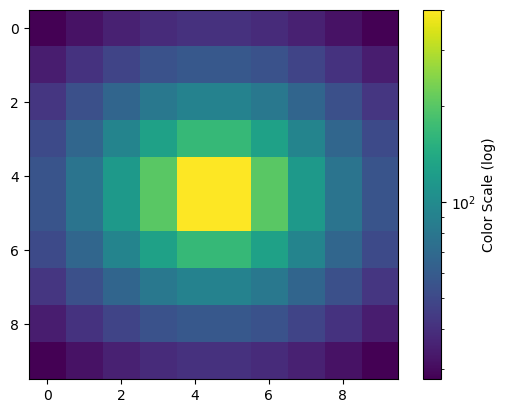

In [104]:
proj_den = projection(densities)
proj_grad = projection(gradients)
plot_img_logscale(proj_den)


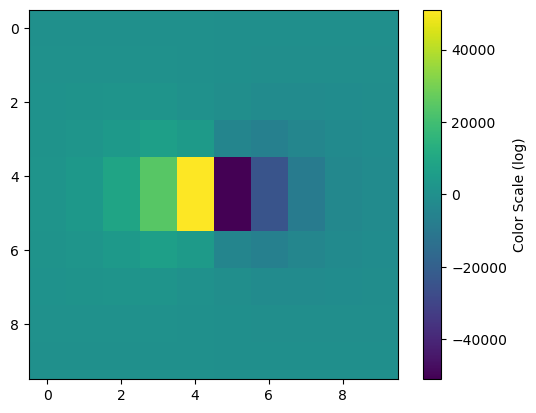

In [105]:
plot_img(gradients[:,:,4,0])

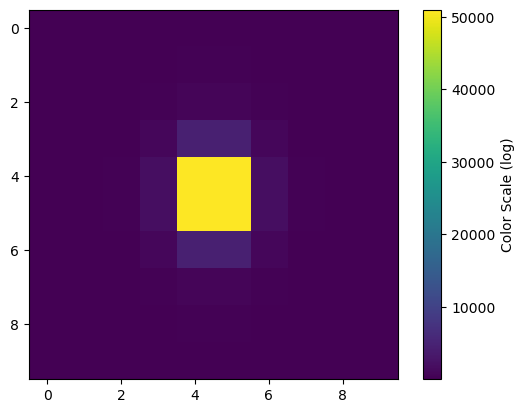

In [106]:
plot_img(gradients[:,4,:,0])

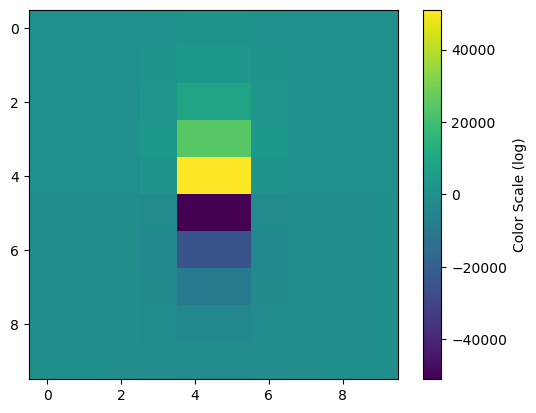

In [153]:
plot_img(gradients[4,:,:,0])

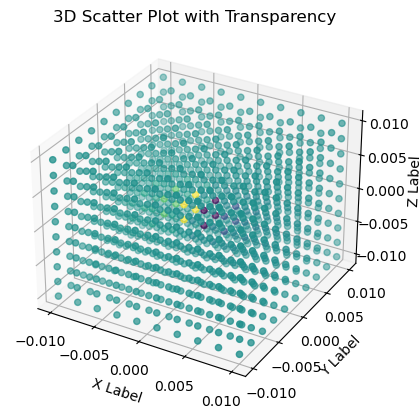

In [108]:
# Set a threshold
threshold = 1  # Adjust as needed



# Generate colors array (assuming you already have it)
colors = gradients[:,:,:,0]  # Example random colors, replace with your actual colors

masked_colors = np.where((colors > threshold) | (colors < -1*threshold) , colors, np.nan)


# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the points with colors and transparency
ax.scatter(x.flatten(),y.flatten(),z.flatten(), c=masked_colors)

# Set labels and title
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.set_title('3D Scatter Plot with Transparency')

# Show plot

plt.show()

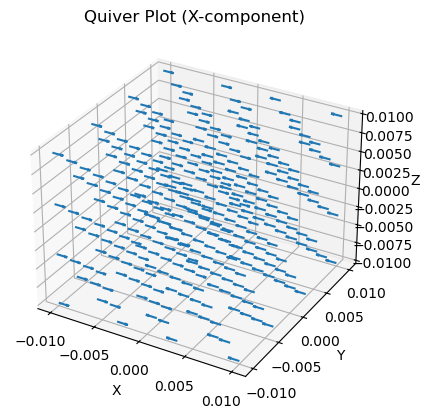

In [109]:

# Compute gradient (assume only x-component)
u = gradients[:,:,:,0]  # Assuming gradients is the computed gradient array

u = u.flatten()

# Set v and w components to zero
v = np.zeros_like(u)
w = np.zeros_like(u)







# Create the quiver plot
fig = plt.figure()


ax = fig.add_subplot(111, projection='3d')
ax.quiver(x.flatten()[::3], y.flatten()[::3], z.flatten()[::3], u[::3], v[::3], w[::3], length=0.0012, normalize=True)

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Quiver Plot (X-component)')
# Show the plot
plt.show()

In [217]:
param = 0
slice = 4
k = gradients[:,:,4,param]
h = np.zeros_like(k)



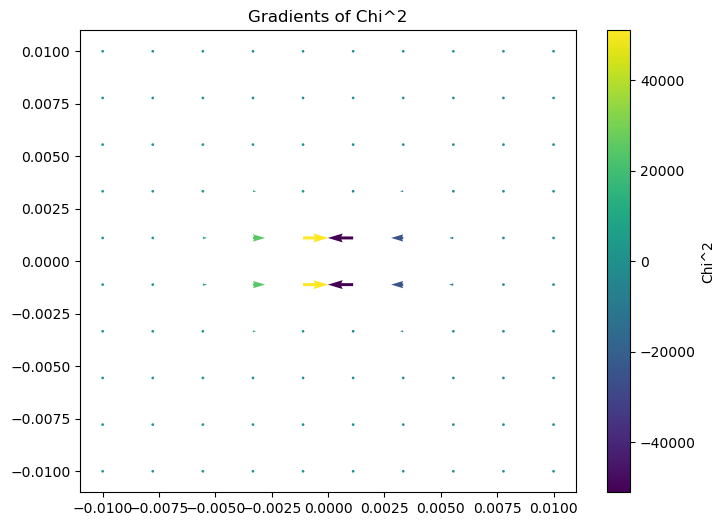

In [220]:
plt.figure(figsize=(8, 6))



plt.title('Chi^2 for Different Parameter Combinations')

plt.quiver(x[:,:,0], y[:,:,0], k, h, k, scale = 1000000)
plt.colorbar(label='Chi^2')
plt.title('Gradients of Chi^2')
plt.show()

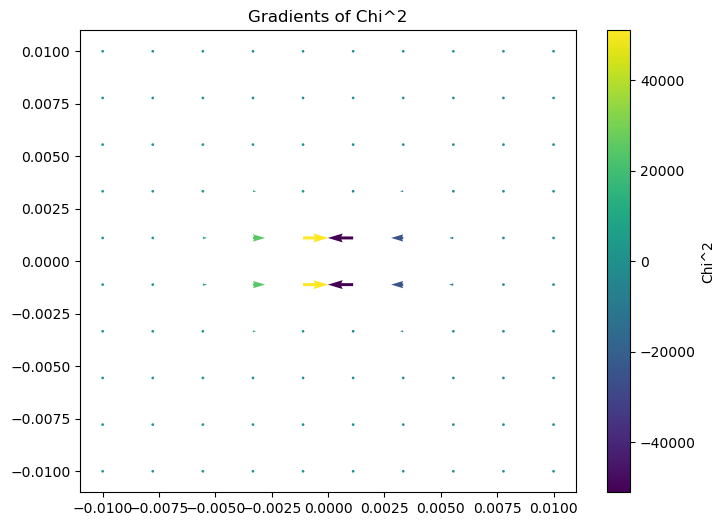

In [221]:
param = 0
slice = 4
k = gradients[:,:,slice,param]
h = np.zeros_like(k)
plt.figure(figsize=(8, 6))



plt.title('Chi^2 for Different Parameter Combinations')

plt.quiver(x[:,:,0], y[:,:,0], k, h, k, scale = 1000000)
plt.colorbar(label='Chi^2')
plt.title('Gradients of Chi^2')
plt.show()

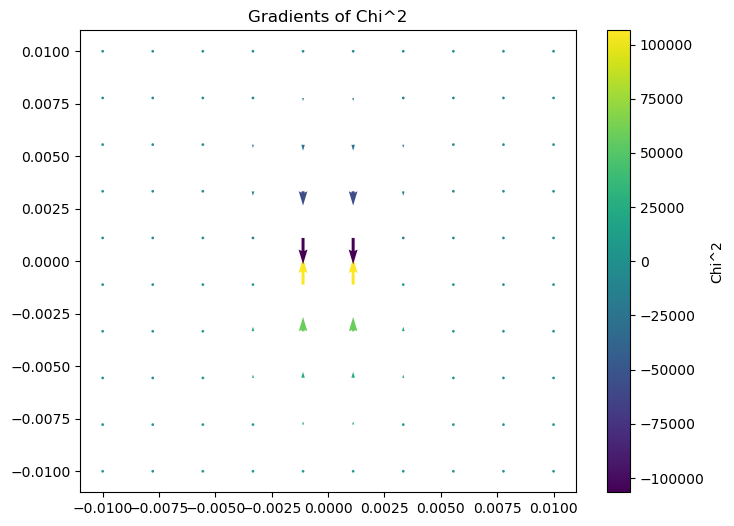

In [223]:
param = 0
slice = 9

proj_grad = projection(gradients[:,:,:,0])
k = proj_grad
h = np.zeros_like(k)
plt.figure(figsize=(8, 6))



plt.title('Chi^2 for Different Parameter Combinations')

plt.quiver(y[:,:,0], x[:,:,0], h, k, k, scale = 2000000)
plt.colorbar(label='Chi^2')
plt.title('Gradients of Chi^2')
plt.show()

In [203]:
proj_grad = projection(gradients[:,:,:,9])
k = proj_grad

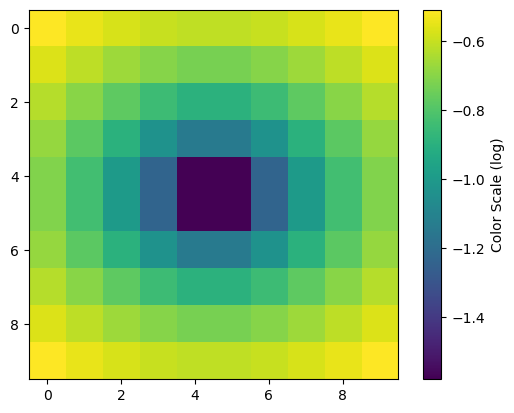

In [204]:
plot_img(k)

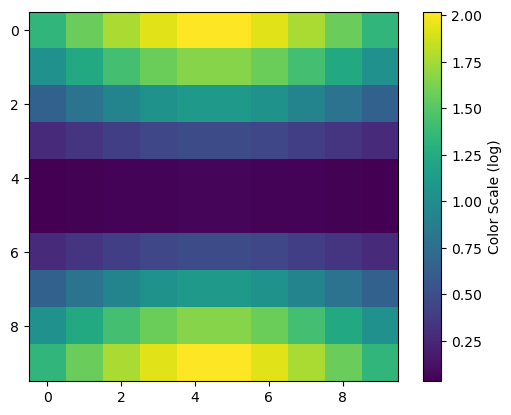

In [213]:
plot_img(gradients[:,:,9,4])

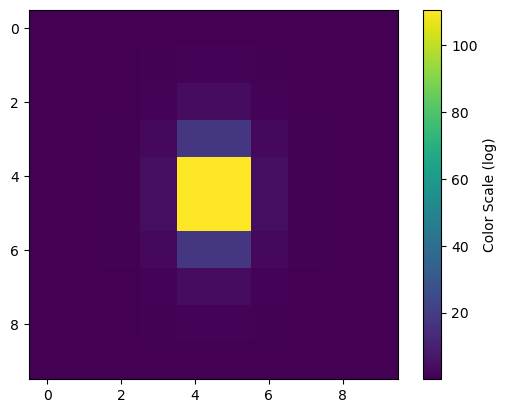

In [181]:
plot_img(gradients[4,:,:,4])

In [227]:

from ipywidgets import interact, IntSlider

def plot_image(index):
    plt.imshow(gradients[:,:,index,9])
    plt.axis('off')
    plt.title('Gradient drho/db along the z-axis')
    plt.show()

interact(plot_image, index=IntSlider(min=0, max=9, step=1, value=0))

interactive(children=(IntSlider(value=0, description='index', max=9), Output()), _dom_classes=('widget-interac…

<function __main__.plot_image(index)>